## 3.Exploratory Data Analysis
This section provides an overview of the demographic, socioeconomic, lifestyle, and health-related characteristics of the NHANES dataset. The goal is to understand variable distributions, detect potential imbalances, and identify patterns that may influence insurance status and hypertension risk.

In [11]:
import pandas as pd
df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes.csv")

### 3.1 Demographics
This section provides a general overview of the demographic characteristics of the population. We focus on age, income–poverty ratio, gender, and education level, which together give us a structural understanding of the socioeconomic background of the dataset.

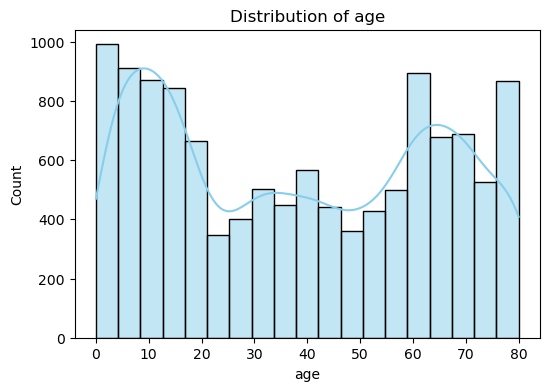

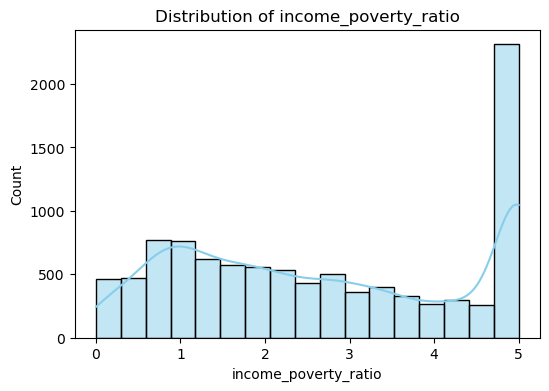

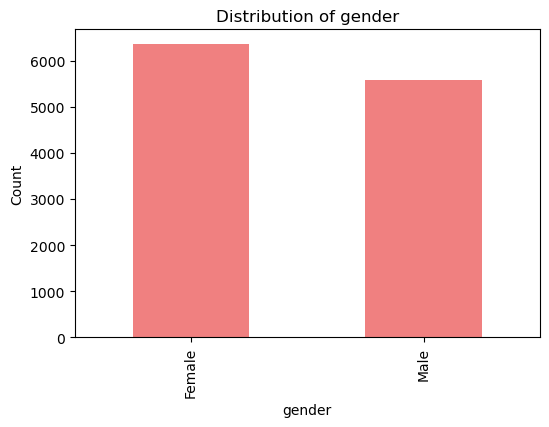

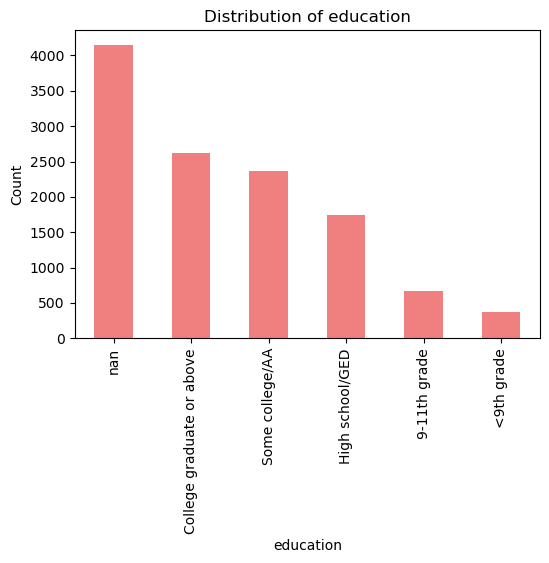

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'income_poverty_ratio']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()

cat_cols = ['gender','education']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Age Distribution**

- The dataset includes participants across all age groups, with notable peaks in younger and older populations.

- This wide spread ensures that hypertension and insurance modeling captures diverse life stages.

**Income-Poverty Ratio Distribution**

- A large number of respondents fall between 0 and 1, indicating a substantial low-income and near-poverty population.
- As the ratio increases from 1 to about 4, the frequency gradually declines, reflecting a smaller middle-income group.
- There is a very sharp spike at exactly 5, which does not mean people’s true ratio is exactly 5, but rather that all respondents with income ≥ 5 times the poverty threshold are censored at this upper bound.

**Gender Distribution**

- Male and Female participants are approximately balanced.

- A well-balanced gender distribution reduces bias in model training.

**Education Level Distribution**

- Most participants fall into "College graduate or above" and "High school/GED" groups.

- Education, as a key SES indicator, may play a role in both health behaviors and insurance access.


### 3.2 Health indicators
This section examines three core physiological health indicators: BMI, SBP, and DBP, which together reflect the population’s cardiometabolic risk profile.

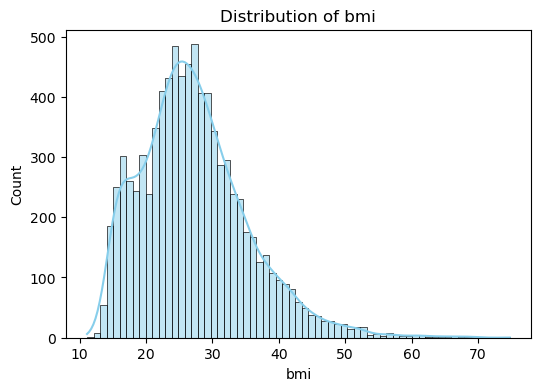

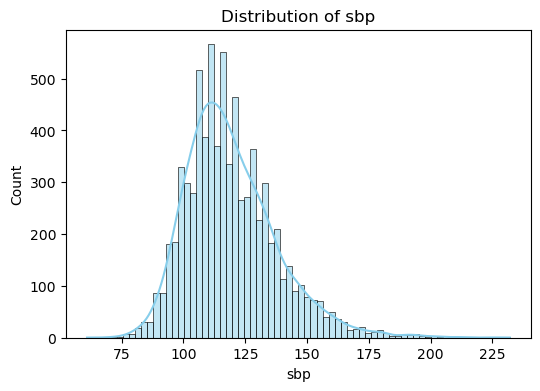

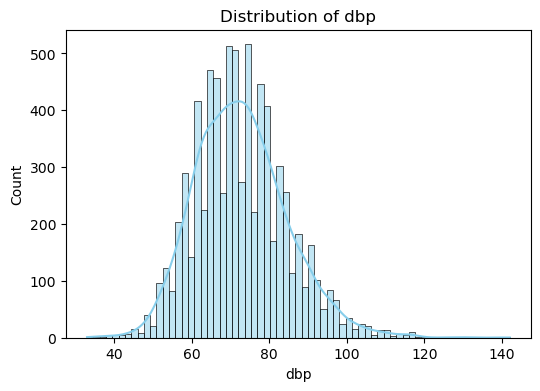

In [25]:
num_cols = ['bmi','sbp', 'dbp']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()

**BMI Distribution**

- BMI follows a right-skewed distribution with a strong concentration between 20–35.

- The long tail toward higher BMI suggests a subgroup with obesity-related risks.

- Since BMI is a known predictor of hypertension, this distribution supports later modeling.

**SBP(Systolic Blood Pressure)**

- SBP shows a moderately right-skewed pattern, with most readings between 110–140 mmHg.

- Readings above 140 indicate a segment already at hypertension Stage 2, important for classification tasks.

**DBP(Diastolic Blood Pressure)**

- DBP peaks around 70–85 mmHg.

- Outliers exceeding 100 mmHg reveal potential high-risk individuals.

### 3.3 Lifestyle
Lifestyle factors capture behavioral patterns that may influence both insurance status and health outcomes. These behavioral variables help us understand how daily habits contribute to the overall health profile of the population

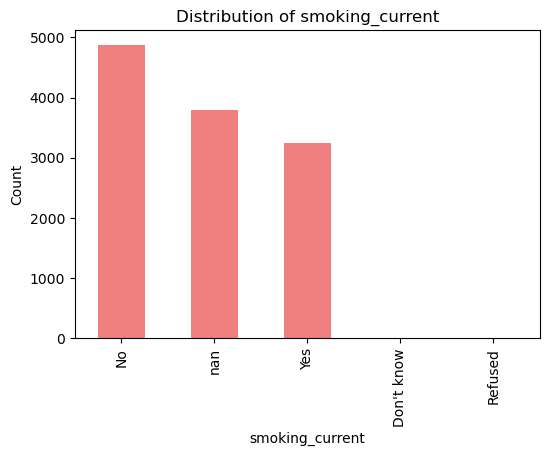

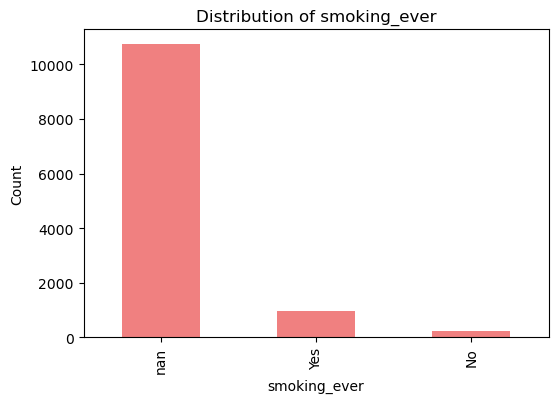

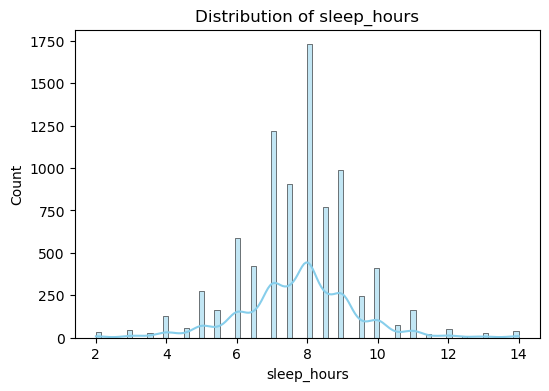

In [23]:
cat_cols = ['smoking_current', 'smoking_ever']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

num_cols = ['sleep_hours']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()


**Smoking Behavior**

**Current Smoking Status**

- Most participants are non-smokers, while a smaller but notable portion reports current smoking.

- Smoking is a major behavioral risk factor for hypertension and is therefore relevant to downstream models.

**Ever Smoked**

Many individuals report having smoked at some point, indicating long-term exposure to cardiovascular risk.


**Sleep Duration**

- Sleep hours are centered around 6–8 hours, with sparse outliers.

- Sleep shortage is often linked to hypertension, making this variable important for clustering.

### 3.4 Insurance status
Understanding insurance status is central to this project. This section visualizes both whether an individual has health insurance and their specific insurance type. To further explore potential disparities, we also plot SBP and DBP across insurance types in this part.

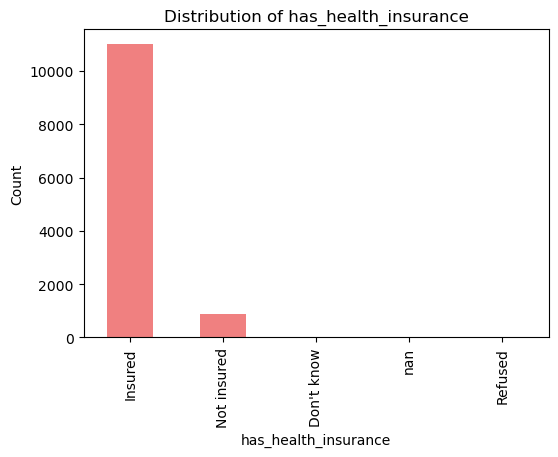

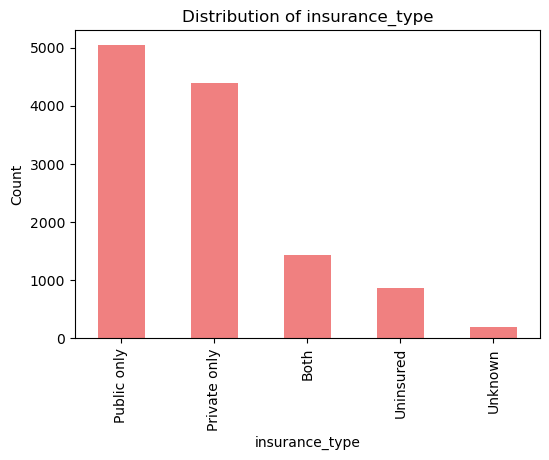

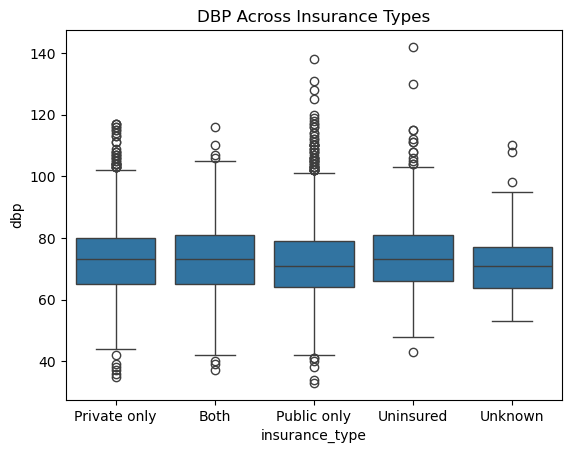

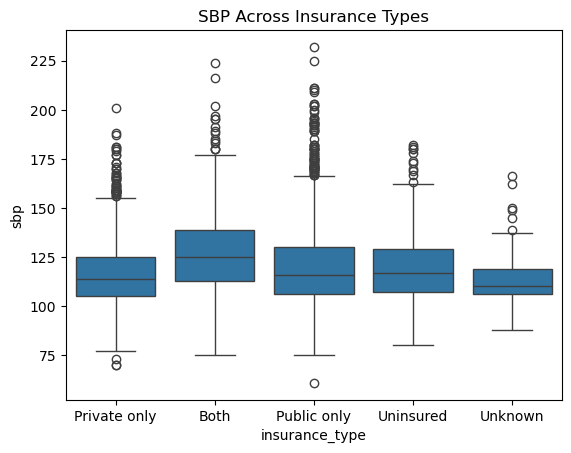

In [22]:
cat_cols = ['has_health_insurance', 'insurance_type']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    
sns.boxplot(x='insurance_type', y='dbp', data=df)
plt.title("DBP Across Insurance Types")
plt.show()

sns.boxplot(x='insurance_type', y='sbp', data=df)
plt.title("SBP Across Insurance Types")
plt.show()

**Health Insurance Coverage**

- A large majority of the population is insured, but a non-trivial portion remains uninsured.

- This supports the project’s motivation to study SES-driven insurance gaps.

**Insurance Type Distribution**

- “Public only” and “Private only” are the two largest categories.

- The “Uninsured” group, while smaller, is essential for comparative analysis of health disparities.

**Blood Pressure Across Insurance Types**

**DBP Across Insurance Types**

- DBP shows visible variation between insurance categories.

- Publicly insured individuals tend to have slightly higher DBP medians, suggesting SES–health linkage.

**SBP Across Insurance Types**

- SBP variation is more pronounced, with uninsured and publicly insured groups showing higher variability.

- This pattern reinforces the hypothesis that insurance type reflects underlying health inequalities.